In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS
from training_configuration import PATHWAYS_3

data = "dream_cytof"
filename = "evaluate_all_figure3"

df = pd.concat(
    pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0).assign(model=model)
    for model in PATHWAYS_3
)

In [2]:
val_df = df[df.dataset == "val"]
val_df.features.fillna("None", inplace=True)

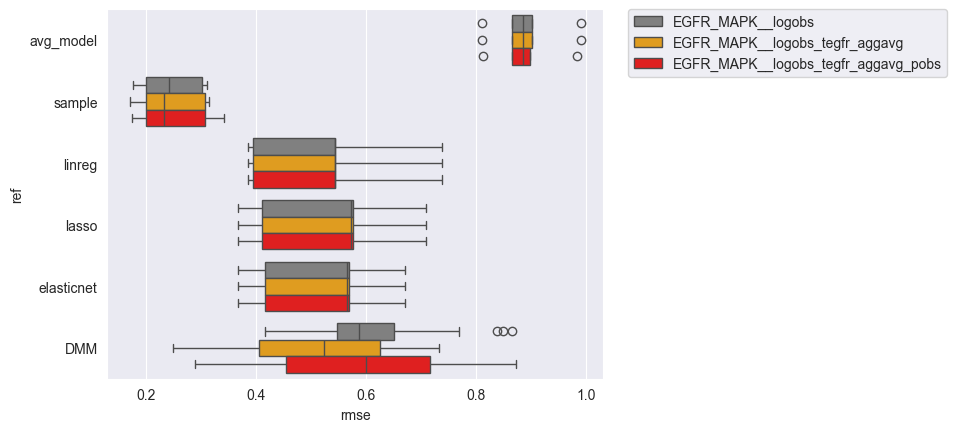

In [3]:
palette = {
    "EGFR_MAPK__logobs": "gray",
    "EGFR_MAPK__logobs_tegfr_aggavg": "orange",
    "EGFR_MAPK__logobs_tegfr_aggavg_pobs": "red",
}

sns.boxplot(
    val_df,
    y="ref",
    x="rmse",
    order=["avg_model", "sample", "linreg", "lasso", "elasticnet", "DMM"],
    hue="model",
    palette=palette
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# Let's zoom in on DMMs only (regressors are not affected by model choice), comparing model/context combos

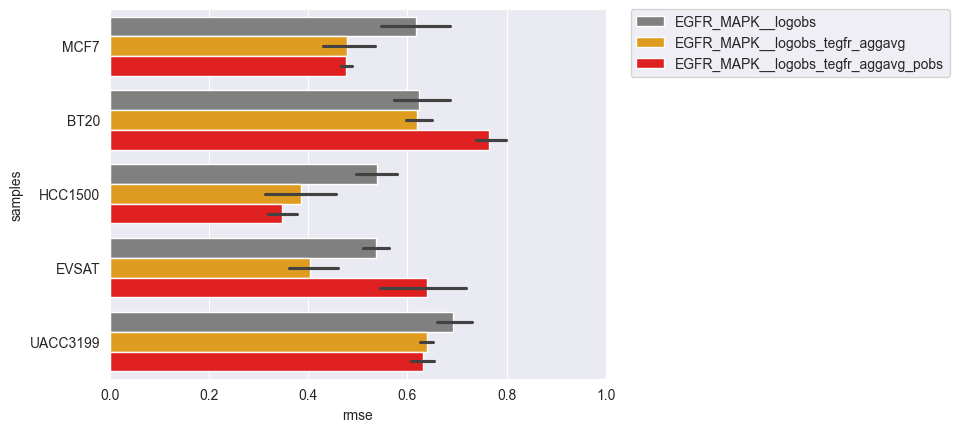

In [4]:
palette = {
    "EGFR_MAPK__logobs": "gray",
    "EGFR_MAPK__logobs_tegfr_aggavg": "orange",
    "EGFR_MAPK__logobs_tegfr_aggavg_pobs": "red",
}

sns.barplot(
    val_df[val_df.ref == "DMM"],
    y="samples",
    x="rmse",
    order=["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"],
    hue="model",
    palette=palette
)
plt.xlim([0, 1])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# `_tegfr` does something different from adding tEGFR to cytof_init - now HCC-1500 and EVSA-T are the ones which improve quite dramatically, followed by UACC-3199, but not really by BT-20, which was our original target...not even the `avg_model` improves on BT-20 with the added `_tegfr` modification..

In [5]:
val_df[val_df.samples == "BT20"].groupby(["model", "ref"]).rmse.mean()

model                                ref       
EGFR_MAPK__logobs                    DMM           0.623201
                                     avg_model     0.865491
                                     elasticnet    0.565474
                                     lasso         0.572285
                                     linreg        0.542606
                                     sample        0.301176
EGFR_MAPK__logobs_tegfr_aggavg       DMM           0.618930
                                     avg_model     0.865491
                                     elasticnet    0.565474
                                     lasso         0.572285
                                     linreg        0.542606
                                     sample        0.306555
EGFR_MAPK__logobs_tegfr_aggavg_pobs  DMM           0.765132
                                     avg_model     0.864489
                                     elasticnet    0.565474
                                     lasso         0

# Let's restrict to `__logobs_tegr_aggavg` and compare with baselines and regressors

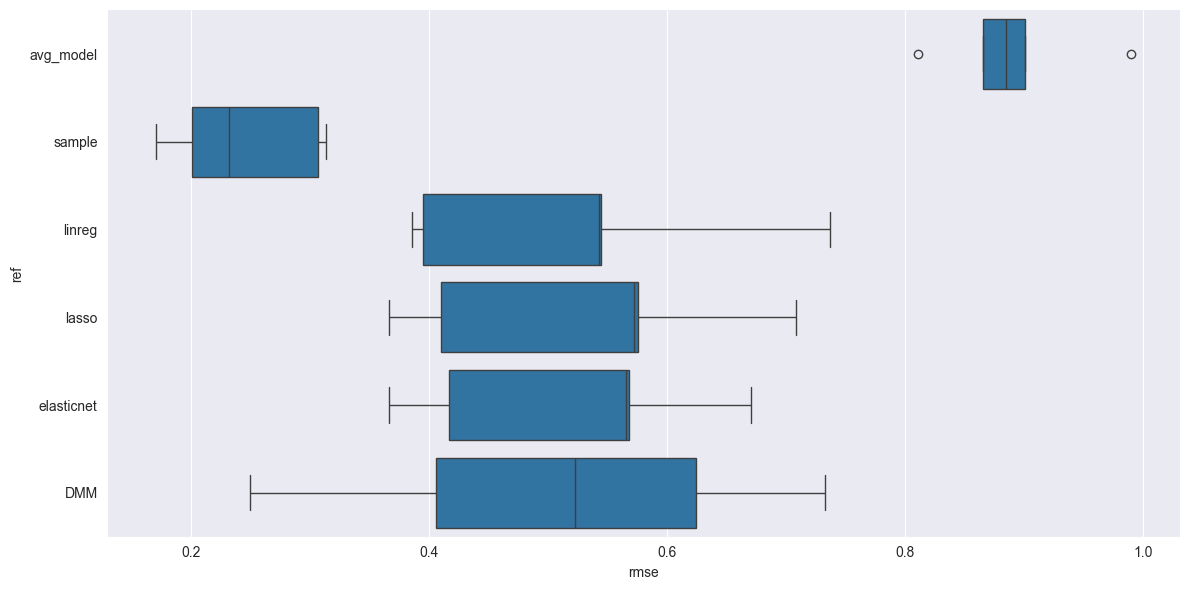

In [6]:
g = sns.FacetGrid(
    val_df[val_df.model == "EGFR_MAPK__logobs_tegfr_aggavg"],
    height=6,
    aspect=2
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="rmse",
    order=["avg_model", "sample", "linreg", "lasso", "elasticnet", "DMM"],
)

In [7]:
from scipy import stats

def kruskal_wallis_groups(df, target_metric, group_metric):
    for context in df['context'].unique():
        context_data = df[df['context'] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}")

# There is a statistically significant difference (improvement) from `__logobs` to `__logobs_tegfr_aggavg`, but not to `__logobs_tegfr_aggavg_pobs`

In [8]:
kruskal_wallis_groups(
    val_df[(val_df.ref.isin(["DMM"])) & (val_df.model.isin(["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]))],
    "rmse",
    "model"
)

Context: cytof_init - Kruskal-Wallis H-test: H-statistic=8.87, p-value=0.0029


In [9]:
groups = [
    val_df[(val_df.ref.isin(["DMM"])) & (val_df.model.isin(["EGFR_MAPK__logobs",]))].sort_values(by="job").rmse.values,
    val_df[(val_df.ref.isin(["DMM"])) & (val_df.model.isin(["EGFR_MAPK__logobs_tegfr_aggavg",]))].sort_values(by="job").rmse.values,
]
stat, p = stats.wilcoxon(*groups, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=191.0, p=5.07e-06


In [10]:
kruskal_wallis_groups(
    val_df[(val_df.ref.isin(["DMM"])) & (val_df.model.isin(["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg_pobs"]))],
    "rmse",
    "model"
)

Context: cytof_init - Kruskal-Wallis H-test: H-statistic=0.36, p-value=0.5487


In [11]:
groups = [
    val_df[(val_df.ref.isin(["DMM"])) & (val_df.model.isin(["EGFR_MAPK__logobs",]))].sort_values(by="job").rmse.values,
    val_df[(val_df.ref.isin(["DMM"])) & (val_df.model.isin(["EGFR_MAPK__logobs_tegfr_aggavg_pobs",]))].sort_values(by="job").rmse.values,
]
stat, p = stats.wilcoxon(*groups, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=522.0, p=0.2695


# We can now compare the tEGFR modification to the fEGFR with added tEGFR via context

In [12]:
from training_configuration import PATHWAYS_2A

data = "dream_cytof"
filename2= "evaluate_all_figure2a"

df2 = pd.concat(
    pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename2), index_col=0).assign(model=model)
    for model in PATHWAYS_2A
)
val_df2 = df2[df2.dataset == "val"]
val_df2.features.fillna("None", inplace=True)

In [13]:
val_df2_fegfr_cytof_tegfr = val_df2[(val_df2.context == "cytof_init_plus_tEGFR") & (val_df2.model == "EGFR_MAPK__logobs_fegfr_aggavg")]

In [14]:
df_comp = pd.concat(
    [
        val_df[val_df.model.isin(["EGFR_MAPK__logobs_tegfr_aggavg"])],
        val_df2_fegfr_cytof_tegfr
    ]
)

In [15]:
groups = [
    df_comp[(df_comp.ref.isin(["DMM"])) & (df_comp.context.isin(["cytof_init"])) & (df_comp.model.isin(["EGFR_MAPK__logobs_tegfr_aggavg",]))].sort_values(by="job").rmse.values,
    df_comp[(df_comp.ref.isin(["DMM"])) & (df_comp.context.isin(["cytof_init_plus_tEGFR"])) & (df_comp.model.isin(["EGFR_MAPK__logobs_fegfr_aggavg",]))].sort_values(by="job").rmse.values,
]
stat, p = stats.wilcoxon(*groups, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=478.0, p=0.1256


# There is no statistical difference, but embedding tEGFR levels in the mechanistic model performs slightly better than passing them as input context. We can also see that the tEGFR information is helpful to regressors, as their performance drops when moving from `fEGFR` with added tEGFR context to `tEGFR` without it.

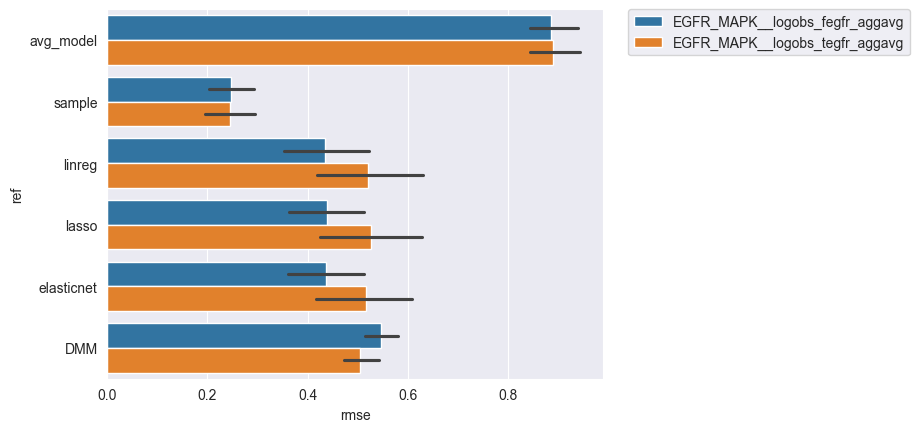

In [16]:
sns.barplot(
    df_comp,
    y="ref",
    x="rmse",
    order=["avg_model", "sample", "linreg", "lasso", "elasticnet", "DMM"],
    hue="model",
    hue_order=["EGFR_MAPK__logobs_fegfr_aggavg", "EGFR_MAPK__logobs_tegfr_aggavg"],
)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

In [17]:
groups = [
    df_comp[(df_comp.ref.isin(["DMM"])) & (df_comp.context.isin(["cytof_init"])) & (df_comp.model.isin(["EGFR_MAPK__logobs_tegfr_aggavg",]))].groupby("samples").rmse.mean().reset_index().sort_values(by="samples").rmse.values,
    df_comp[(df_comp.ref.isin(["elasticnet"])) & (df_comp.context.isin(["cytof_init_plus_tEGFR"])) & (df_comp.model.isin(["EGFR_MAPK__logobs_fegfr_aggavg",]))].sort_values(by="samples").rmse.values,
]
stat, p = stats.wilcoxon(*groups, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=4.0, p=0.4375


# No statistically significant difference between elasticnet with added tEGFR and DMMs without (but tEGFR in mechanistic model)